In [1]:
#url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Load Dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# Define features and target
features = df[['total_bill', 'size']]
target = df['tip']

print("Features: \n", features.head())
print("Target: \n", target.head())

Features: 
    total_bill  size
0       16.99     2
1       10.34     3
2       21.01     3
3       23.68     2
4       24.59     4
Target: 
 0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print("Training Data Set: ", X_train.shape)
print("Testing Data Set: ", X_test.shape)

Training Data Set:  (195, 2)
Testing Data Set:  (49, 2)


In [10]:
# predict tip amount based on total bill and size of the party
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [11]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error: ", mse)
print("R^2 Score: ", r2)

Mean Squared Error:  0.6485996190543516
R^2 Score:  0.4811084097989492


In [15]:
# predict by human given total bill and size of the party
def predict_tip(total_bill, size):
    return model.predict([[total_bill, size]])[0]
# Example usage
predicted_tip = predict_tip(7, 4)
print("Predicted Tip for a $50 bill and a party of 4: ", predicted_tip)


Predicted Tip for a $50 bill and a party of 4:  2.2643754419919384


c:\Users\Kamran\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


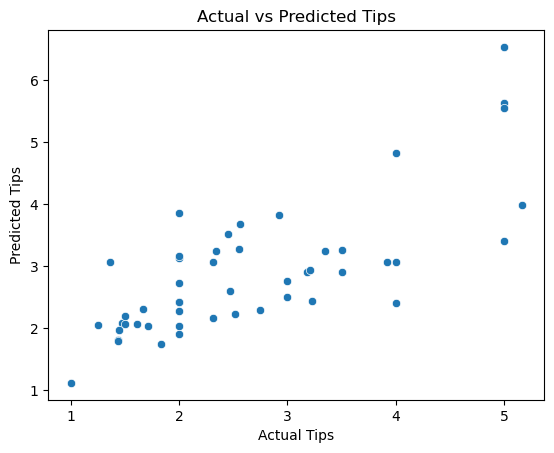

In [12]:
# Visualize the results
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")
plt.title("Actual vs Predicted Tips")
plt.show()


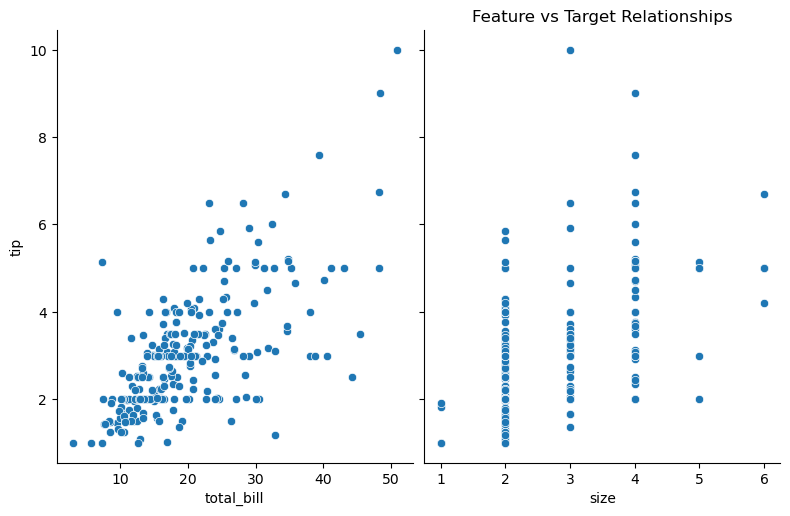

In [6]:
# Visualize relationships
sns.pairplot(df, x_vars=["total_bill", "size"], y_vars="tip", height=5, aspect=0.8, kind="scatter")
plt.title("Feature vs Target Relationships")
plt.show()
